In [ ]:
!pip install xgboost

Loading the weather data from CSV.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,OneHotEncoder,FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score,precision_score,f1_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv("weatherAUS.csv")

drop_col = set()

In [ ]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


In [ ]:
df["month"] = pd.to_datetime(df["Date"]).dt.month

drop_col.add("Date")

In [ ]:
df["month"] = pd.to_datetime(df["Date"]).dt.month # Extracting month from the Date column.

drop_col.add("Date")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [ ]:
df_eda = df.drop("Date",axis=1).copy()

df_eda = df_eda.dropna()

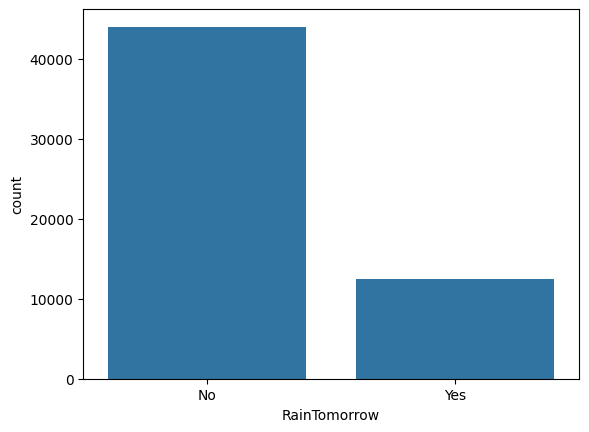

In [ ]:
sns.countplot(x=df_eda["RainTomorrow"])
plt.show()

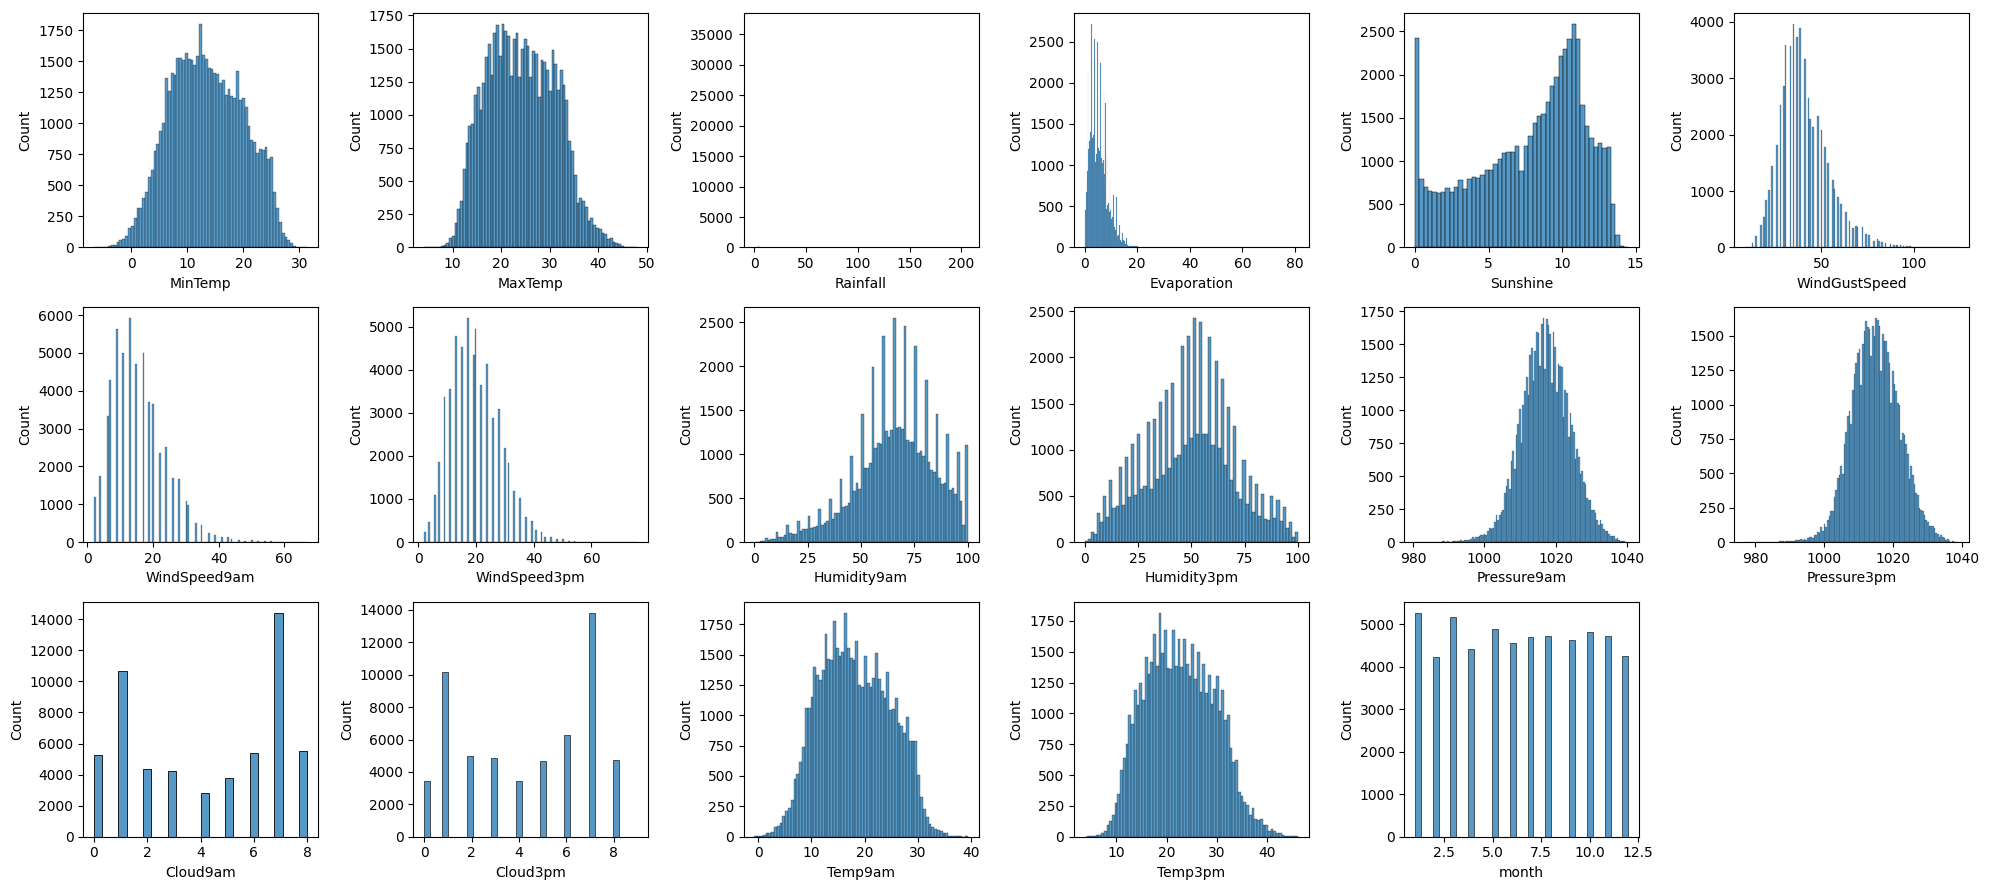

In [ ]:
num_col = df_eda.select_dtypes(include=np.number).columns

plt.figure(figsize=(20,9))
for i ,val in enumerate(num_col):
  plt.subplot(3,6,i+1)
  sns.histplot(df_eda[val])
  plt.tight_layout()

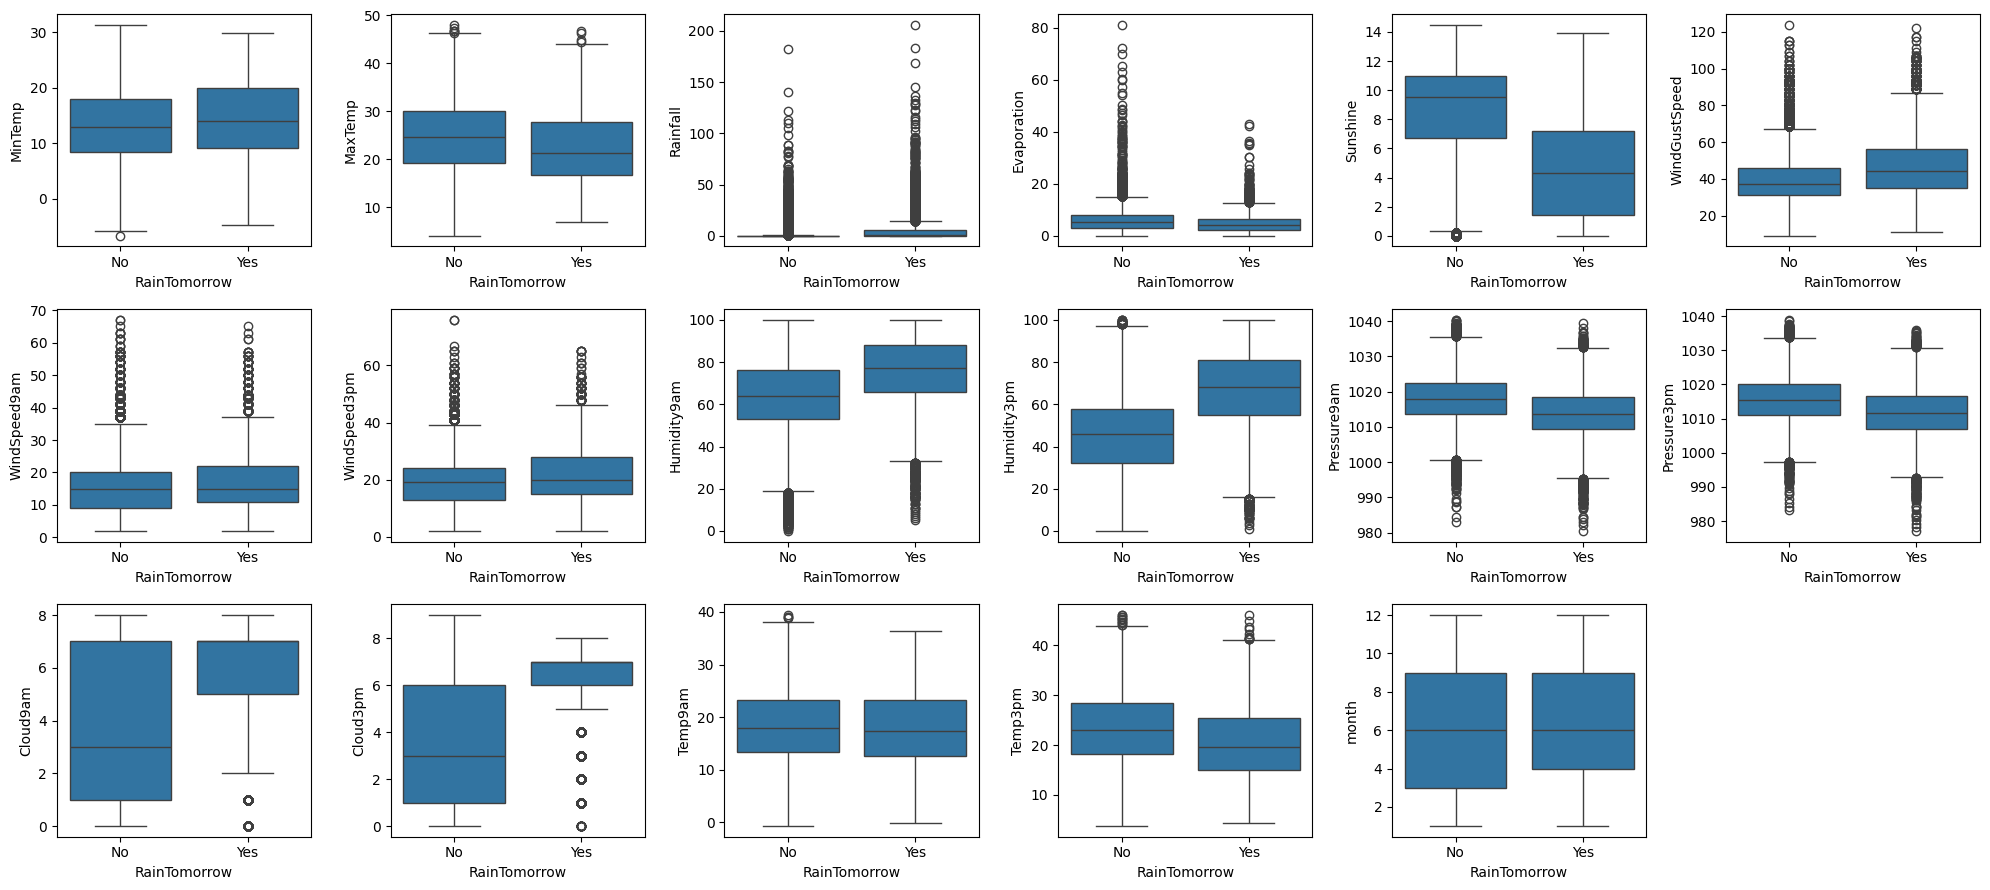

In [ ]:
plt.figure(figsize=(20,9))
for i ,val in enumerate(num_col):
  plt.subplot(3,6,i+1)
  sns.boxplot(x= "RainTomorrow",y=val,data=df_eda)
  plt.tight_layout()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X  = df_eda[num_col]
y = df_eda["RainTomorrow"]

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X,y)

importance = pd.DataFrame(model.feature_importances_,index=X.columns).sort_values(ascending=False,by=0)

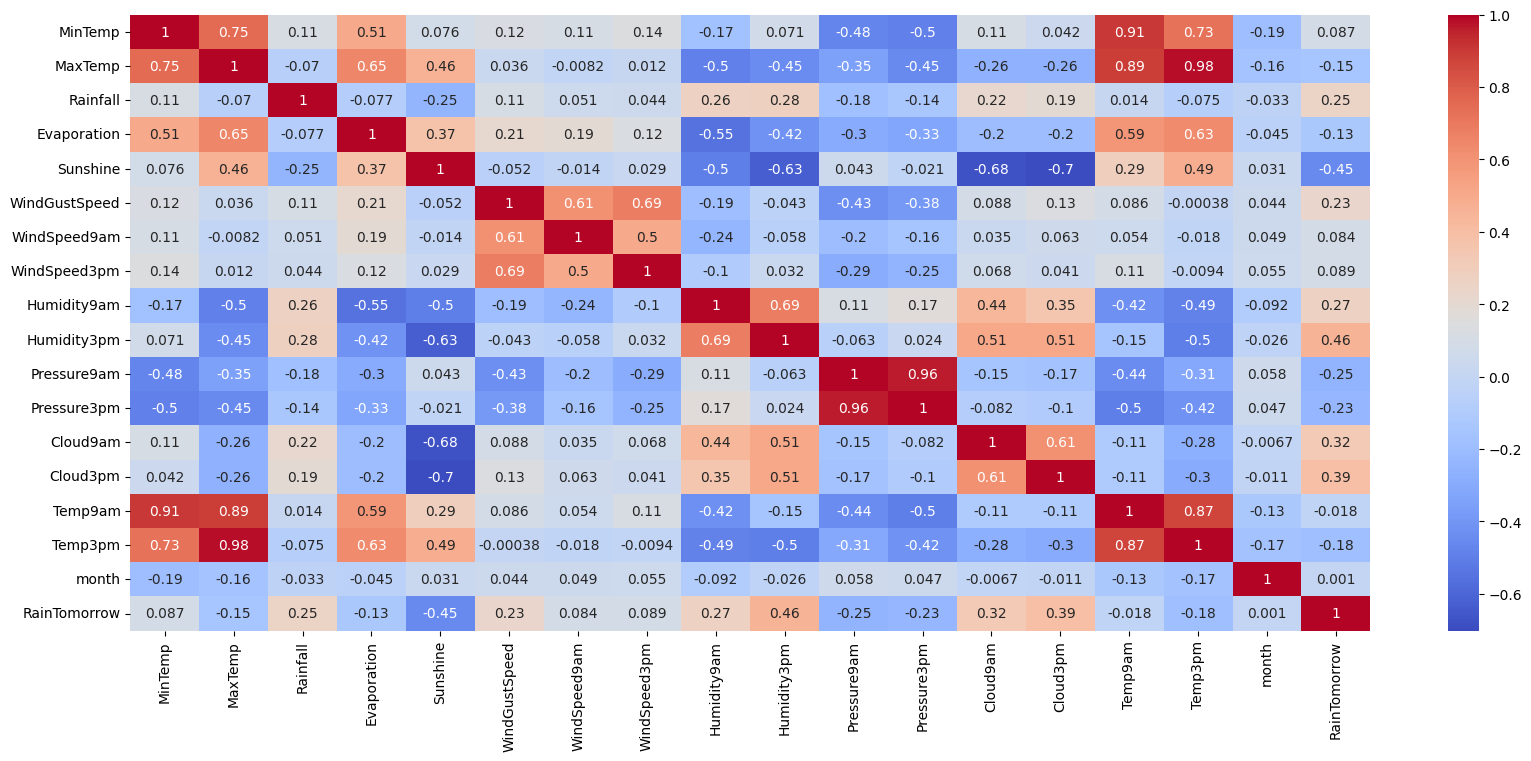

In [ ]:
df_eda["RainTomorrow"] = df_eda["RainTomorrow"].map({"No":0,"Yes":1})
corr_col = num_col.tolist()+["RainTomorrow"]
corr = df_eda[corr_col].corr()
plt.figure(figsize=(20,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

In [ ]:
df["temp_change"] =  df["Temp3pm"] - df["Temp9am"]
df["pressure_change"] =  df["Pressure3pm"] - df["Pressure9am"]

drop_col.update(["Temp3pm","Temp9am","Pressure3pm","Pressure9am"])

In [ ]:
df["temp_change"] =  df["Temp3pm"] - df["Temp9am"] # Calculating temperature and pressure changes.
df["pressure_change"] =  df["Pressure3pm"] - df["Pressure9am"]

drop_col.update(["Temp3pm","Temp9am","Pressure3pm","RainToday","Pressure9am"])

In [ ]:
top_5_location = df_eda["Location"].value_counts(ascending=False)[:5]
df_eda["Location"] = np.where(df_eda["Location"].isin(top_5_location.index), df_eda["Location"], "other")
categorical_col = df_eda.select_dtypes(include="object").columns


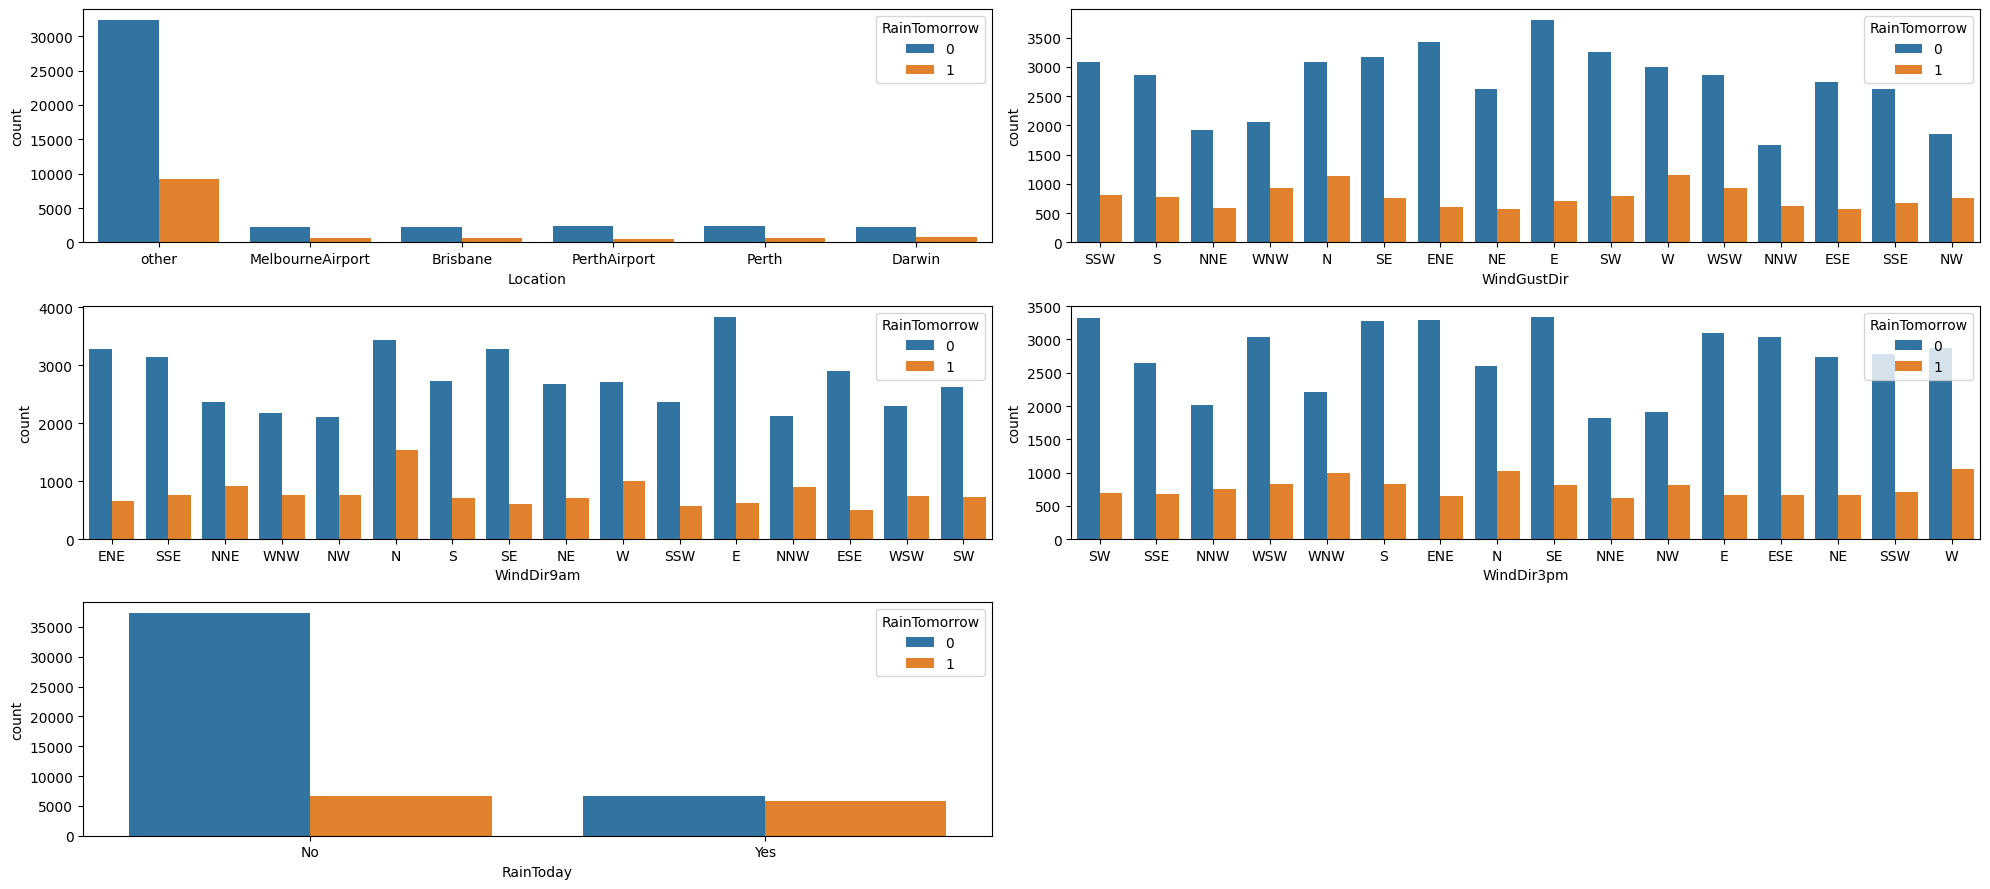

In [ ]:
plt.figure(figsize=(20,9))
for i,col in enumerate(categorical_col):
  plt.subplot(3,2,i+1)
  sns.countplot(x=df_eda[col],hue=df_eda["RainTomorrow"])
  plt.tight_layout()

In [ ]:
df_model = df.drop(drop_col,axis=1).copy()

In [ ]:
df["RainTomorrow"].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
df_model["RainTomorrow"] = df_model["RainTomorrow"].map({"Yes":1,"No":0})

df_model = df_model.dropna(subset=["RainTomorrow"]).reset_index(drop=True)
df_model.isnull().sum()

,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013
WindDir3pm,3778


In [ ]:
df_model["RainTomorrow"] = df_model["RainTomorrow"].map({"Yes":1,"No":0}) # Mapping target 'Yes'/'No' to 1/0.

df_model = df_model.dropna(subset=["RainTomorrow"]).reset_index(drop=True)
df_model.isnull().sum()

In [ ]:
X = df_model.drop("RainTomorrow",axis=1)
y = df_model["RainTomorrow"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y) # set stratify is y because our target is imbalanced

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y) # Splitting data with stratification due to imbalance.

In [ ]:
num_col = X.select_dtypes(include=np.number).columns.drop("Evaporation").tolist()
cat_col = X.select_dtypes(include="object").columns
log_col = ["Evaporation"]

In [ ]:
class outlier(BaseEstimator,TransformerMixin):
  def __init__(self,factor=1.5):
    self.factor = factor
    self.upper_ = None
    self.lower_ = None

  def fit(self,X,y=None):
    X_df = pd.DataFrame(X)
    Q1 = X_df.quantile(0.25)
    Q3 = X_df.quantile(0.75)

    IQR = Q3-Q1
    self.upper_ = Q3 + self.factor *IQR
    self.lower_ = Q1 - self.factor *IQR

    return self

  def transform(self,X):
    X_df = pd.DataFrame(X).copy()

    return X_df.clip(lower=self.lower_,upper=self.upper_, axis=1)

In [ ]:
class outlier(BaseEstimator,TransformerMixin):
  def __init__(self,factor=1.5):
    self.factor = factor
    self.upper_ = None
    self.lower_ = None

  def fit(self,X,y=None):
    X_df = pd.DataFrame(X)
    Q1 = X_df.quantile(0.25)
    Q3 = X_df.quantile(0.75)

    IQR = Q3-Q1
    self.upper_ = Q3 + self.factor *IQR
    self.lower_ = Q1 - self.factor *IQR

    return self

  def transform(self,X):
    X_df = pd.DataFrame(X).copy()

    return X_df.clip(lower=self.lower_,upper=self.upper_, axis=1) # Clipping outliers based on IQR.

In [ ]:
# numerical pipeline

numerical_pipeline = Pipeline(
    steps=[
       ("imputer",SimpleImputer(strategy="mean")),
       ("outlier",outlier(factor=1.5)),
       ("scaling",StandardScaler())

    ])

# log transform pipeline
log_pipeline = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="mean")),
        ("log",FunctionTransformer(np.log1p)),
        ("outlier",outlier(factor=1.5)),
        ("scaling",StandardScaler()),
    ]
)


# categorical pipeline


categorical_pipeline = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("onehot",OneHotEncoder(drop="first",max_categories=6,handle_unknown="infrequent_if_exist"))
    ]
)

#column transformer

preprocessor = ColumnTransformer([
    ("numerical",numerical_pipeline,num_col),
    ("categorical",categorical_pipeline,cat_col),
    ("log_transform",log_pipeline,log_col)

])


Setting up the main preprocessor for all features.

In [ ]:
def final_pipeline(model):
  return Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("model",model)
    ]
)

In [ ]:
def final_pipeline(model): # Helper to build full pipeline with preprocessing and model.
  return Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("model",model)
    ]
)

In [ ]:
logistic_regression = final_pipeline(LogisticRegression(random_state=42))
logistic_regression.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('outlier',
                                                                   outlier()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Sunshine',
                                                   'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'month', 'temp_change',
                                                   'pressure_change'...
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 max_categories=6))]),
                                                  Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], dtype='object')),
                                                 ('log_transform',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('outlier',
                                                                   outlier()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['Evaporation'])])),
                ('model', LogisticRegression(random_state=42))])

Training Logistic Regression model.

In [ ]:
lr_pred = logistic_regression.predict(X_test)

In [ ]:
print(f1_score(y_test,lr_pred))

0.5865331107401224


In [ ]:
random_forest = final_pipeline(RandomForestClassifier(random_state=42,class_weight="balanced"))

param_grid = {
    "model__n_estimators" : [100,200],
    "model__max_depth" : [10,20],
}

rf_model = GridSearchCV(
    estimator = random_forest,
    param_grid = param_grid,
    cv=3,
    scoring ="f1",
    n_jobs =-1
)

rf_model.fit(X_train,y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('outlier',
                                                                                          outlier()),
                                                                                         ('scaling',
                                                                                          StandardScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Sunshine',
                                                                          'WindGustSpeed',
                                                                          'WindSpeed9am',
                                                                          'WindSpeed3pm',
                                                                          'Humidity9am',
                                                                          'Humidity3pm',
                                                                          'Cloud9am',
                                                                          'Cloud3pm',
                                                                          'month',
                                                                          'te...
                                                                        ('log_transform',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('log',
                                                                                          FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                         ('outlier',
                                                                                          outlier()),
                                                                                         ('scaling',
                                                                                          StandardScaler())]),
                                                                         ['Evaporation'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

Training Random Forest model with GridSearchCV.

In [ ]:
print(f1_score(y_test,rf_model.predict(X_test)))

0.6276756899163538


In [ ]:
xgb_model_pipeline = final_pipeline(XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False))

param_grid_xgb = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10,20],
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_model_pipeline,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

xgb_grid_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('outlier',
                                                                                          outlier()),
                                                                                         ('scaling',
                                                                                          StandardScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Sunshine',
                                                                          'WindGustSpeed',
                                                                          'WindSpeed9am',
                                                                          'WindSpeed3pm',
                                                                          'Humidity9am',
                                                                          'Humidity3pm',
                                                                          'Cloud9am',
                                                                          'Cloud3pm',
                                                                          'month',
                                                                          'te...
                                                      learning_rate=None,
                                                      max_bin=None,
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20],
                         'model__n_estimators': [50, 100]},
             scoring='f1')

Training XGBoost model with GridSearchCV.

In [ ]:
print(f"Best F1 score for XGBoost on cross-validation: {xgb_grid_search.best_score_}")
print(f"Best parameters for XGBoost: {xgb_grid_search.best_params_}")

xgb_pred = xgb_grid_search.predict(X_test)
print(f"F1 score for XGBoost on test set: {f1_score(y_test, xgb_pred)}")

Best F1 score for XGBoost on cross-validation: 0.6149664190098479
Best parameters for XGBoost: {'model__max_depth': 20, 'model__n_estimators': 100}
F1 score for XGBoost on test set: 0.6193304535637149


In [ ]:
from sklearn.ensemble import VotingClassifier


estimators = [
    ('lr', logistic_regression),
    ('rf', rf_model.best_estimator_),
    ('xgb', xgb_grid_search.best_estimator_)
]

voting_clf = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

Building and training the Voting Classifier.

In [ ]:
voting_clf.fit(X_train, y_train)

voting_pred = voting_clf.predict(X_test)
print(f"F1 score for Voting Classifier on test set: {f1_score(y_test, voting_pred)}")

F1 score for Voting Classifier on test set: 0.6344983481133716


In [ ]:
# --- FINAL PROJECT SUMMARY & CONCLUSION ---

print("="*60)
print("🎯 WEATHER PREDICTION PIPELINE: FINAL PERFORMANCE REPORT")
print("="*60)

# 1. Base Models Evaluation
print(f" Logistic Regression Test F1-Score : {f1_score(y_test, lr_pred):.4f}")
print(f" Random Forest Test F1-Score        : {f1_score(y_test, rf_model.predict(X_test)):.4f}")
print(f" XGBoost Classifier Test F1-Score   : {f1_score(y_test, xgb_pred):.4f}")
print("-"*60)

# 2. Final Ensemble Model Evaluation
print(f" FINAL ENSEMBLE (VOTING) F1-SCORE   : {f1_score(y_test, voting_pred):.4f}")
print("="*60)

# 3. Final Takeaway Print
print(" Project Status: Completed & Evaluated Successfully.")
print("ℹ Note: Model pipeline is fully insulated against data leakage and ready for production.")
print("="*60)

🎯 WEATHER PREDICTION PIPELINE: FINAL PERFORMANCE REPORT
 Logistic Regression Test F1-Score : 0.5865
 Random Forest Test F1-Score        : 0.6277
 XGBoost Classifier Test F1-Score   : 0.6193
------------------------------------------------------------
 FINAL ENSEMBLE (VOTING) F1-SCORE   : 0.6345
 Project Status: Completed & Evaluated Successfully.
ℹ Note: Model pipeline is fully insulated against data leakage and ready for production.
